<a href="https://colab.research.google.com/github/Ariqq16/PCVK_Ganjil_2026/blob/main/P4/Tugas_E2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

E2 NO.1


/tmp/ipykernel_625/578529561.py:39: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[1, 0].hist(img_gray.ravel(), 256, [0, 256], color='gray')
/tmp/ipykernel_625/578529561.py:42: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[1, 1].hist(img_manual.ravel(), 256, [0, 256], color='blue', alpha=0.7)
/tmp/ipykernel_625/578529561.py:45: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[1, 2].hist(img_cv.ravel(), 256, [0, 256], color='red', alpha=0.7)


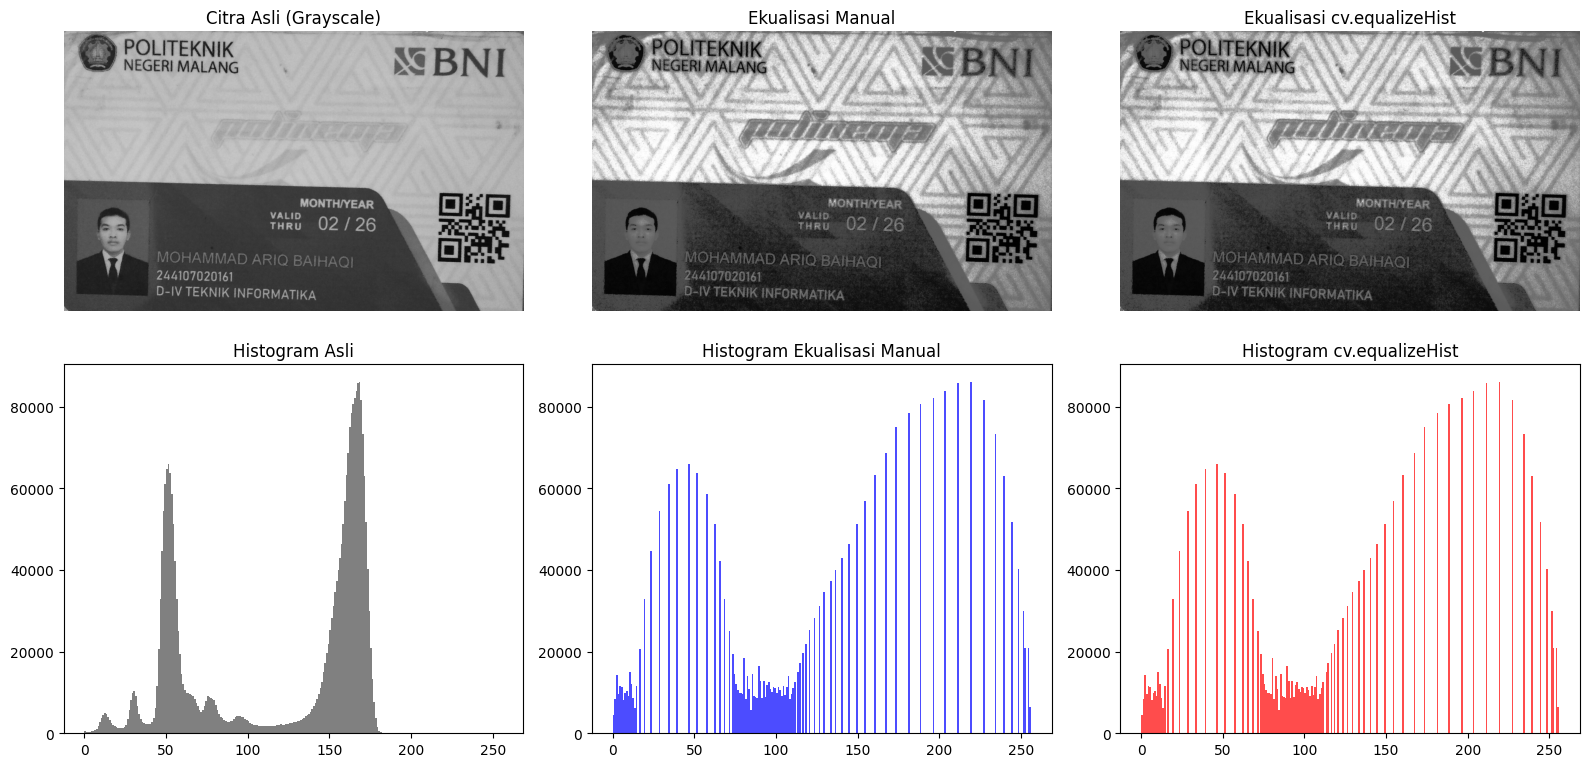

MSE: 1109.63
PSNR (Citra Asli vs Hasil Ekualisasi): 17.68 dB


In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os

BASE = '/content/drive/MyDrive/PCVK_2026/'
path_ktm = os.path.join(BASE, 'KTM1a.jpg')

img_gray = cv.imread(path_ktm, cv.IMREAD_GRAYSCALE)

if img_gray is None:
    raise FileNotFoundError(f"File tidak ditemukan di {path_ktm}")

hist, _ = np.histogram(img_gray.flatten(), 256, [0, 256])
cdf = hist.cumsum()
cdf_normalized = cdf / img_gray.size
skala_warna = np.round(cdf_normalized * 255).astype(np.uint8)
img_manual = skala_warna[img_gray]

img_cv = cv.equalizeHist(img_gray)

# 1b.
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Baris 1: Citra
axes[0, 0].imshow(img_gray, cmap='gray')
axes[0, 0].set_title('Citra Asli (Grayscale)')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_manual, cmap='gray')
axes[0, 1].set_title('Ekualisasi Manual')
axes[0, 1].axis('off')

axes[0, 2].imshow(img_cv, cmap='gray')
axes[0, 2].set_title('Ekualisasi cv.equalizeHist')
axes[0, 2].axis('off')

# Baris 2: Histogram
axes[1, 0].hist(img_gray.ravel(), 256, [0, 256], color='gray')
axes[1, 0].set_title('Histogram Asli')

axes[1, 1].hist(img_manual.ravel(), 256, [0, 256], color='blue', alpha=0.7)
axes[1, 1].set_title('Histogram Ekualisasi Manual')

axes[1, 2].hist(img_cv.ravel(), 256, [0, 256], color='red', alpha=0.7)
axes[1, 2].set_title('Histogram cv.equalizeHist')

plt.tight_layout()
plt.show()

# 1c.Perhitungan PSNR
def hitung_psnr(asli, olah):
    mse = np.mean((asli.astype(float) - olah.astype(float)) ** 2)
    if mse == 0:
        return float('inf')
    max_pixel = 255.0
    psnr = 20 * np.log10(max_pixel / np.sqrt(mse))
    return psnr, mse

psnr_val, mse_val = hitung_psnr(img_gray, img_cv)
print(f"MSE: {mse_val:.2f}")
print(f"PSNR (Citra Asli vs Hasil Ekualisasi): {psnr_val:.2f} dB")

E2 No.2


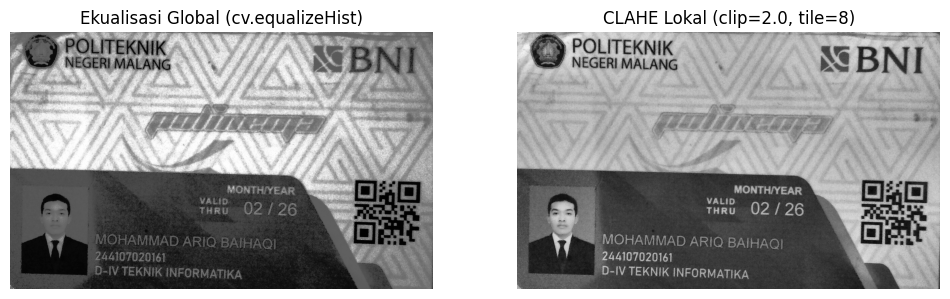

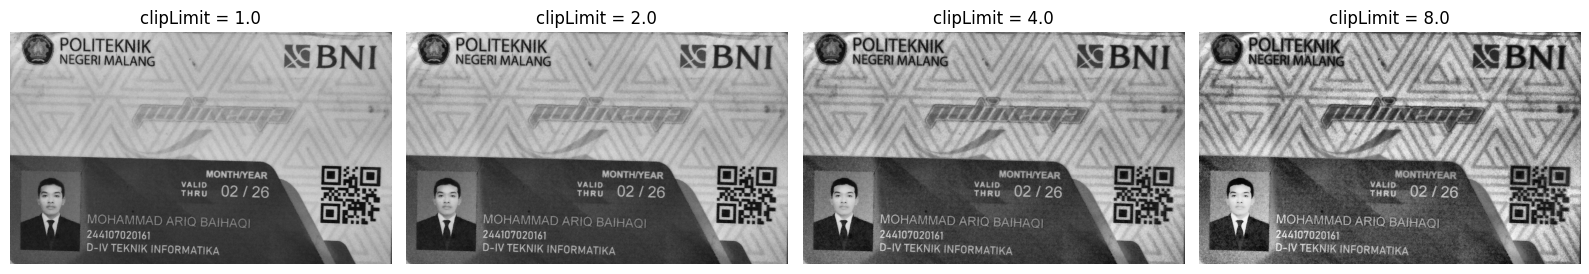

In [2]:
PARAM = {'clip': 2.0, 'tile': 8}

# 2a
clahe_main = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
img_clahe = clahe_main.apply(img_gray)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_cv, cmap='gray')
plt.title('Ekualisasi Global (cv.equalizeHist)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_clahe, cmap='gray')
plt.title(f"CLAHE Lokal (clip={PARAM['clip']}, tile={PARAM['tile']})")
plt.axis('off')
plt.show()

# 2b
clip_limits = [1.0, PARAM['clip'], 4.0, 8.0]

plt.figure(figsize=(16, 4))
for i, clip in enumerate(clip_limits, 1):
    clahe_exp = cv.createCLAHE(clipLimit=clip, tileGridSize=(PARAM['tile'], PARAM['tile']))
    res = clahe_exp.apply(img_gray)

    plt.subplot(1, 4, i)
    plt.imshow(res, cmap='gray')
    plt.title(f"clipLimit = {clip}")
    plt.axis('off')

plt.tight_layout()
plt.show()